# Praktikum 02: Ekstraksi Fitur Tradisional
### Deteksi Sudut Harris · SIFT vs ORB · Homografi & Panorama

**Visi Komputer 2026 — Minggu 02 — Sesi Asdos (50 menit)**

Notebook ini punya beberapa sel bertanda **`# TODO`**. Isi baris itu berdasarkan penjelasan
di slide. Setiap blok TODO ditutup satu sel **pemeriksa** yang mencetak `OK` atau pesan
kesalahan, dan satu sel **penyelamat** (disembunyikan) berisi jawaban siap jalan kalau kalian
buntu lebih dari dua menit — buka saja sel itu, jalankan, dan lanjut ke blok berikutnya.

Jalankan di **Google Colab**. Tidak perlu memasang ulang OpenCV/NumPy — semuanya sudah
tersedia di Colab bawaan.

## Nama: Davidson Rafael Krisman Nugroho
## NIM: 412024030

## 0 · Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from skimage import data

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("SIFT tersedia:", hasattr(cv2, "SIFT_create"))
print("ORB tersedia :", hasattr(cv2, "ORB_create"))

OpenCV : 5.0.0
NumPy  : 2.1.3
SIFT tersedia: True
ORB tersedia : True


In [2]:
def show(*images_titles, figsize=(13, 5)):
    """
    Tampilkan beberapa citra BGR/gray berdampingan. Tiap argumen: (citra, judul).
    """
    n = len(images_titles)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, (im, title) in zip(axes, images_titles):
        if im.ndim == 2:
            ax.imshow(im, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Data yang dipakai hari ini

Dua data uji, sudah disiapkan supaya hasilnya identik untuk semua orang dan tidak perlu unggah
berkas:

1. **Papan catur sintetis** — posisi setiap sudutnya diketahui persis, dipakai untuk menguji
   detektor Harris terhadap koordinat yang benar-benar tepat.
2. **Pasangan foto beririsan** — dipotong dari satu foto nyata (`skimage.data.astronaut`), lalu
   salah satu potongannya diberi transformasi perspektif dengan matriks `H_true` yang kita
   tentukan sendiri. Karena `H_true` diketahui, hasil estimasi homografi kalian nanti bisa
   diukur ketepatannya dalam satuan piksel, bukan dinilai dengan mata.

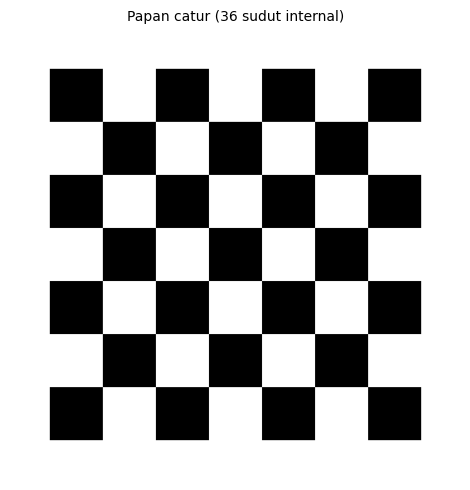

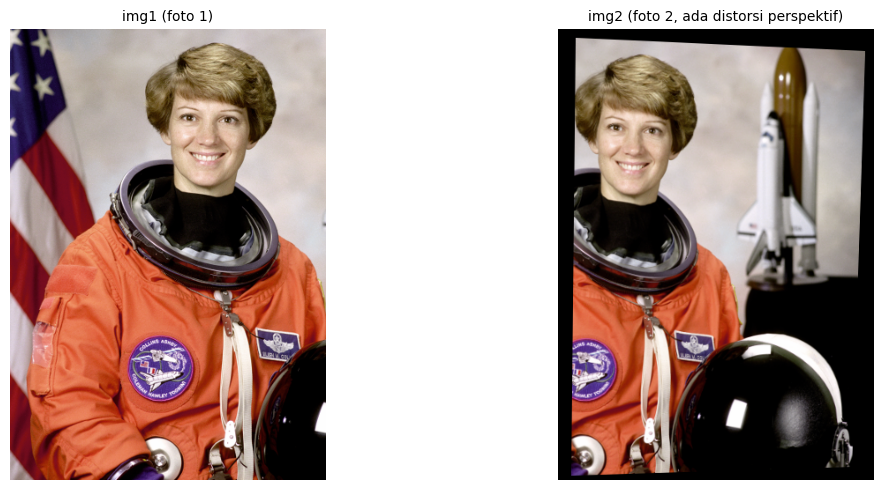

In [3]:
def make_chessboard(rows=7, cols=7, square=40, border=30):
    """
    Papan catur sintetis + koordinat (x, y) tiap sudut internal (ground truth)."""
    h = square * rows + 2 * border
    w = square * cols + 2 * border
    img = np.full((h, w), 255, dtype=np.uint8)
    for r in range(rows):
        for c in range(cols):
            if (r + c) % 2 == 0:
                y0, y1 = border + r * square, border + (r + 1) * square
                x0, x1 = border + c * square, border + (c + 1) * square
                img[y0:y1, x0:x1] = 0
    gt_corners = [(border + c * square, border + r * square)
                  for r in range(1, rows) for c in range(1, cols)]
    return img, gt_corners


def make_image_pair(overlap_frac=0.4):
    """
    Dua foto beririsan dari satu foto nyata, plus H_true (img1 -> img2) yang sebenarnya.
    """
    rgb = data.astronaut()
    img = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]
    overlap_w = int(w * overlap_frac)
    split = w // 2
    left_w = split + overlap_w // 2
    right_w = split - overlap_w // 2

    img1 = img[:, :left_w].copy()
    img2_src = img[:, right_w:].copy()

    h2, w2 = img2_src.shape[:2]
    src_pts = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]])
    dst_pts = np.float32([[20, 10], [w2 - 10, 25], [w2 - 25, h2 - 15], [15, h2 - 5]])
    H_warp = cv2.getPerspectiveTransform(src_pts, dst_pts)
    img2 = cv2.warpPerspective(img2_src, H_warp, (w2, h2))

    T = np.array([[1, 0, -right_w], [0, 1, 0], [0, 0, 1]], dtype=np.float64)
    H_true = H_warp @ T
    return img1, img2, H_true


chessboard, gt_corners = make_chessboard()
img1, img2, H_true = make_image_pair()

show((chessboard, f"Papan catur ({len(gt_corners)} sudut internal)"))
show((img1, "img1 (foto 1)"), (img2, "img2 (foto 2, ada distorsi perspektif)"))

---
## Blok 1 · Detektor Sudut Harris (± 11 menit)

**Dari slide:** matriks momen kedua $M = \sum w(x,y)\begin{bmatrix}I_x^2 & I_xI_y\\ I_xI_y & I_y^2\end{bmatrix}$
dan fungsi respons sudut

$$R = \det(M) - k \cdot \text{trace}(M)^2$$

Gradien ($I_x$, $I_y$) sudah dihitung dengan `cv2.Sobel`, dan jendela pembobot $w(x,y)$ sudah
diterapkan dengan `cv2.GaussianBlur`. **Tugas kalian: lengkapi rumus $R$.**

In [4]:
def harris_response(gray_img, k=0.04):
    gray_f = gray_img.astype(np.float32)
    Ix = cv2.Sobel(gray_f, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray_f, cv2.CV_64F, 0, 1, ksize=3)
    Ixx, Iyy, Ixy = Ix ** 2, Iy ** 2, Ix * Iy

    Sxx = cv2.GaussianBlur(Ixx, (5, 5), sigmaX=1.0)
    Syy = cv2.GaussianBlur(Iyy, (5, 5), sigmaX=1.0)
    Sxy = cv2.GaussianBlur(Ixy, (5, 5), sigmaX=1.0)

    det_M = (Sxx * Syy) - (Sxy ** 2)
    trace_M = Sxx + Syy

    # TODO: lengkapi rumus respons sudut Harris R = det(M) - k * trace(M)^2
    R = det_M - k * (trace_M**2)

    return R

Non-maximum suppression sudah ditulis lengkap (fungsinya tidak sederhana untuk ditulis dari
nol dalam 11 menit) — tugas kalian hanya memilih **ambang** yang dipakai untuk memutuskan mana
respons yang cukup kuat untuk disebut sudut.

Piksel di atas ambang TANPA non-maximum suppression : 144
Titik sudut SETELAH non-maximum suppression          : 144


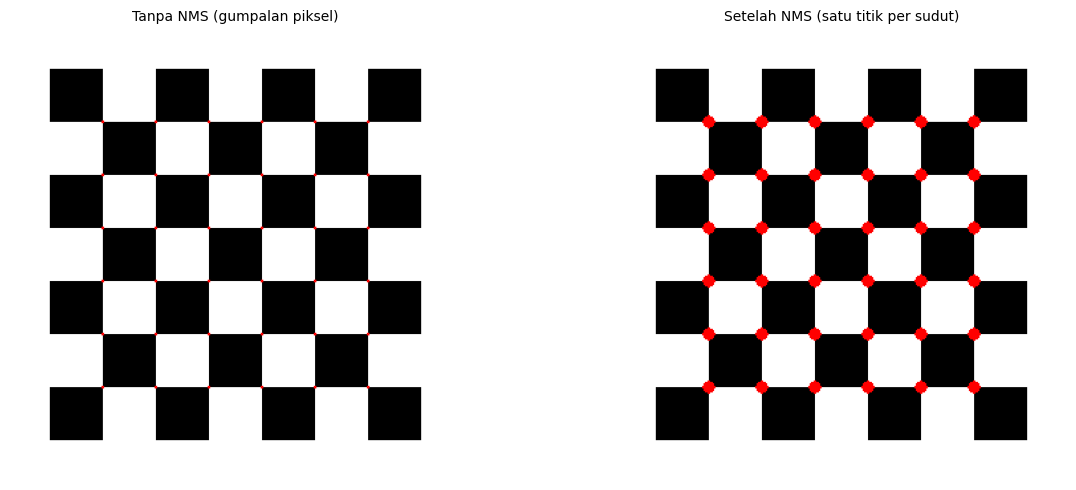

In [5]:
def non_max_suppression(R, threshold_ratio, window=7):
    threshold = threshold_ratio * R.max()
    local_max = (R == maximum_filter(R, size=window))
    return (R > threshold) & local_max


R = harris_response(chessboard)

# TODO: pilih ambang (pecahan dari R.max()) untuk memisahkan sudut dari area datar/tepi.
# Coba mulai dari sekitar 0.01 -- terlalu kecil akan menangkap noise, terlalu besar akan
# kehilangan sudut yang lemah.

nms_threshold_ratio = 0.95

corners_mask = non_max_suppression(R, threshold_ratio=nms_threshold_ratio)
raw_mask = R > (nms_threshold_ratio * R.max())

print(f"Piksel di atas ambang TANPA non-maximum suppression : {raw_mask.sum()}")
print(f"Titik sudut SETELAH non-maximum suppression          : {corners_mask.sum()}")

vis = cv2.cvtColor(chessboard, cv2.COLOR_GRAY2BGR)
vis_raw = vis.copy()
vis_raw[raw_mask] = [0, 0, 255]
vis_nms = vis.copy()
ys, xs = np.where(corners_mask)
for x, y in zip(xs, ys):
    cv2.circle(vis_nms, (x, y), 4, (0, 0, 255), -1)

show((vis_raw, "Tanpa NMS (gumpalan piksel)"), (vis_nms, "Setelah NMS (satu titik per sudut)"))

**Sel pemeriksa** — jalankan setelah mengisi kedua TODO di atas.

In [6]:
# PEMERIKSA BLOK 1

def _check_blok1():
    assert R is not ..., "R belum diisi -- lengkapi rumus Harris di sel sebelumnya."
    assert nms_threshold_ratio is not ..., "nms_threshold_ratio belum diisi."
    detected = np.argwhere(corners_mask)  # (row, col) = (y, x)
    detected_xy = [(int(c), int(r)) for r, c in detected]
    tol = 5
    matched = 0
    for gx, gy in gt_corners:
        if any(abs(dx - gx) <= tol and abs(dy - gy) <= tol for dx, dy in detected_xy):
            matched += 1
    frac = matched / len(gt_corners)
    print(f"Sudut ground-truth yang berhasil dideteksi: {matched}/{len(gt_corners)} ({frac:.0%})")
    assert frac >= 0.85, "Kurang dari 85% sudut asli terdeteksi -- cek ulang rumus R atau ambang."
    assert corners_mask.sum() <= len(gt_corners) * 4, (
        "Terlalu banyak titik terdeteksi -- kemungkinan ambang terlalu rendah."
    )
    print("OK -- detektor Harris bekerja dengan benar.")

_check_blok1()

Sudut ground-truth yang berhasil dideteksi: 36/36 (100%)
OK -- detektor Harris bekerja dengan benar.


<details><summary><b>🆘 Sel penyelamat Blok 1</b> (buka kalau buntu &gt; 2 menit)</summary>

```python
def harris_response(gray_img, k=0.04):
    gray_f = gray_img.astype(np.float32)
    Ix = cv2.Sobel(gray_f, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray_f, cv2.CV_64F, 0, 1, ksize=3)
    Ixx, Iyy, Ixy = Ix ** 2, Iy ** 2, Ix * Iy
    Sxx = cv2.GaussianBlur(Ixx, (5, 5), sigmaX=1.0)
    Syy = cv2.GaussianBlur(Iyy, (5, 5), sigmaX=1.0)
    Sxy = cv2.GaussianBlur(Ixy, (5, 5), sigmaX=1.0)
    det_M = (Sxx * Syy) - (Sxy ** 2)
    trace_M = Sxx + Syy
    R = det_M - k * (trace_M ** 2)
    return R

R = harris_response(chessboard)
nms_threshold_ratio = 0.01
corners_mask = non_max_suppression(R, threshold_ratio=nms_threshold_ratio)
```

Jalankan ulang sel visualisasi dan sel pemeriksa setelah menempelkan kode ini.
</details>

In [7]:
# Pembanding: fungsi bawaan OpenCV (untuk cek rasa, bukan wajib sama persis)
R_cv = cv2.cornerHarris(chessboard.astype(np.float32), blockSize=5, ksize=3, k=0.04)
print("Korelasi R buatan sendiri vs cv2.cornerHarris:",
      np.corrcoef(R.flatten(), R_cv.flatten())[0, 1].round(4))

Korelasi R buatan sendiri vs cv2.cornerHarris: 0.7999


---
## Blok 2 · SIFT vs ORB (± 13 menit)

**Dari slide:** SIFT menghasilkan deskriptor *float* 128 dimensi (tahan skala, rotasi,
pencahayaan). ORB menghasilkan deskriptor biner 256 bit (BRIEF di atas keypoint FAST
berorientasi), jauh lebih cepat tapi kurang tahan perubahan skala besar.

In [55]:
sift = cv2.SIFT_create()

# TODO: buat detektor ORB dengan jumlah fitur maksimum 2000 (argumen nfeatures)
orb = cv2.ORB_create(2000)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

kp1_sift, des1_sift = sift.detectAndCompute(gray1, None)
kp2_sift, des2_sift = sift.detectAndCompute(gray2, None)
kp1_orb, des1_orb = orb.detectAndCompute(gray1, None)
kp2_orb, des2_orb = orb.detectAndCompute(gray2, None)

print(f"SIFT: {len(kp1_sift)} keypoint di img1 | deskriptor shape={des1_sift.shape} dtype={des1_sift.dtype}")
print(f"ORB : {len(kp1_orb)} keypoint di img1 | deskriptor shape={des1_orb.shape} dtype={des1_orb.dtype}")

SIFT: 921 keypoint di img1 | deskriptor shape=(921, 128) dtype=float32
ORB : 1947 keypoint di img1 | deskriptor shape=(1947, 32) dtype=uint8


Perhatikan baris output di atas: SIFT `(N, 128) float32`, ORB `(N, 32) uint8` (32 byte = 256
bit). Bentuk yang beda total ini artinya keduanya **tidak boleh dicocokkan dengan cara yang
sama** — SIFT pakai jarak Euclidean (`NORM_L2`), ORB pakai jarak Hamming (`NORM_HAMMING`,
menghitung jumlah bit yang beda). Lengkapi keduanya di bawah, plus ambang *Lowe's ratio test*.

In [56]:
def match_with_ratio_test(des1, des2, norm, ratio=0.75):
    bf = cv2.BFMatcher(norm)
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]
    return good

# TODO: norma jarak yang benar untuk tiap jenis deskriptor
NORM_SIFT = cv2.NORM_L2   # cv2.NORM_L2 atau cv2.NORM_HAMMING?
NORM_ORB = cv2.NORM_HAMMING    # cv2.NORM_L2 atau cv2.NORM_HAMMING?

# TODO: ambang Lowe's ratio test (semakin kecil = semakin ketat/pilih-pilih)
lowe_ratio = 0.7

good_sift = match_with_ratio_test(des1_sift, des2_sift, NORM_SIFT, lowe_ratio)
good_orb = match_with_ratio_test(des1_orb, des2_orb, NORM_ORB, lowe_ratio)

print(f"SIFT: {len(good_sift)} pasangan baik dari {len(des1_sift)} keypoint")
print(f"ORB : {len(good_orb)} pasangan baik dari {len(des1_orb)} keypoint")

SIFT: 354 pasangan baik dari 921 keypoint
ORB : 487 pasangan baik dari 1947 keypoint


**Sel pemeriksa**

In [57]:
# ======================= PEMERIKSA BLOK 2 =======================
def _check_blok2():
    assert NORM_SIFT is not ... and NORM_ORB is not ..., "NORM_SIFT / NORM_ORB belum diisi."
    assert NORM_SIFT == cv2.NORM_L2, "SIFT pakai deskriptor float -- norma yang benar NORM_L2."
    assert NORM_ORB == cv2.NORM_HAMMING, "ORB pakai deskriptor biner -- norma yang benar NORM_HAMMING."
    assert lowe_ratio is not ..., "lowe_ratio belum diisi."
    assert 0.5 <= lowe_ratio <= 0.9, "lowe_ratio di luar rentang wajar (biasanya 0.6-0.8)."
    assert len(good_sift) >= 50, f"Pasangan SIFT terlalu sedikit ({len(good_sift)}) -- cek norma/rasio."
    assert len(good_orb) >= 50, f"Pasangan ORB terlalu sedikit ({len(good_orb)}) -- cek norma/rasio."
    print(f"OK -- SIFT {len(good_sift)} pasangan, ORB {len(good_orb)} pasangan, keduanya wajar.")

_check_blok2()

OK -- SIFT 354 pasangan, ORB 487 pasangan, keduanya wajar.


<details><summary><b>🆘 Sel penyelamat Blok 2</b></summary>

```python
orb = cv2.ORB_create(nfeatures=2000)
NORM_SIFT = cv2.NORM_L2
NORM_ORB = cv2.NORM_HAMMING
lowe_ratio = 0.75
```
</details>

ORB + NORM_HAMMING (benar) : 487 pasangan baik
ORB + NORM_L2 (salah)      : 197 pasangan baik
-> Tidak error sama sekali, hanya diam-diam menghasilkan pasangan yang lebih sedikit/buruk.


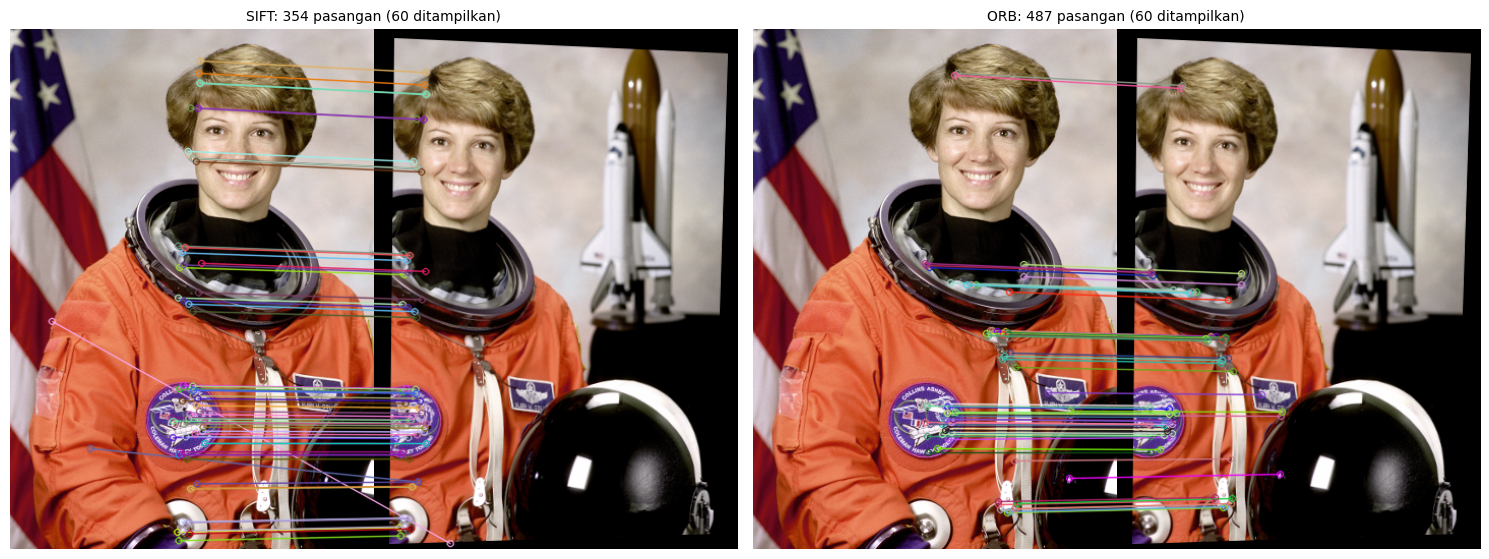

In [58]:
# Bukti kenapa norma harus sesuai jenis deskriptor: pasangkan ORB pakai NORM_L2 (SALAH, tapi tidak error)
good_orb_wrong_norm = match_with_ratio_test(
    des1_orb.astype(np.float32), des2_orb.astype(np.float32), cv2.NORM_L2, lowe_ratio
)
print(f"ORB + NORM_HAMMING (benar) : {len(good_orb)} pasangan baik")
print(f"ORB + NORM_L2 (salah)      : {len(good_orb_wrong_norm)} pasangan baik")
print("-> Tidak error sama sekali, hanya diam-diam menghasilkan pasangan yang lebih sedikit/buruk.")

img_matches_sift = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift, good_sift[:60], None,
                                    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
img_matches_orb = cv2.drawMatches(img1, kp1_orb, img2, kp2_orb, good_orb[:60], None,
                                   flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show((img_matches_sift, f"SIFT: {len(good_sift)} pasangan (60 ditampilkan)"),
     (img_matches_orb, f"ORB: {len(good_orb)} pasangan (60 ditampilkan)"), figsize=(15, 6))

---
## Blok 3 · Homografi & Panorama (± 14 menit)

**Dari slide:** homografi $H$ (matriks 3&times;3, 8 derajat kebebasan) memetakan satu bidang
citra ke bidang citra lain. RANSAC dipakai supaya beberapa pasangan yang salah (dari Blok 2,
pasti masih ada sisa yang lolos rasio Lowe tapi sebenarnya salah) tidak merusak estimasi.

In [67]:
def estimate_homography(kp1, kp2, good_matches, ransac_thresh):
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    return H, mask

# TODO: ambang RANSAC dalam piksel (ransacReprojThreshold) -- jarak maksimum agar suatu
# pasangan masih dianggap inlier. Coba mulai dari sekitar 5.0.
ransac_thresh = 5.0

H_est, inlier_mask = estimate_homography(kp1_sift, kp2_sift, good_sift, ransac_thresh)
n_inliers = int(inlier_mask.sum())
print(f"Inlier RANSAC: {n_inliers}/{len(good_sift)} pasangan ({n_inliers/len(good_sift):.0%})")
print("H_est =\n", H_est)

Inlier RANSAC: 349/354 pasangan (99%)
H_est =
 [[ 9.91146840e-01 -9.06836290e-03 -1.32151259e+02]
 [ 4.67678101e-02  1.02770694e+00  3.03053187e+00]
 [ 1.51818038e-04  6.76304118e-05  1.00000000e+00]]


**Sel pemeriksa** — mengukur H_est terhadap H_true yang sebenarnya, dalam satuan piksel.

In [68]:
# ======================= PEMERIKSA BLOK 3a (homografi) =======================
def _check_blok3a():
    assert ransac_thresh is not ..., "ransac_thresh belum diisi."
    assert H_est is not None, "cv2.findHomography gagal -- kurang dari 4 pasangan baik?"
    h1_, w1_ = img1.shape[:2]
    corners1 = np.float32([[0, 0], [w1_, 0], [w1_, h1_], [0, h1_]]).reshape(-1, 1, 2)
    proj_est = cv2.perspectiveTransform(corners1, H_est)
    proj_true = cv2.perspectiveTransform(corners1, H_true)
    err = np.linalg.norm(proj_est - proj_true, axis=2).mean()
    print(f"Galat reproyeksi H_est vs H_true (4 sudut img1): {err:.2f} piksel")
    assert err < 15.0, "Galat reproyeksi terlalu besar -- cek ransac_thresh atau pasangan Blok 2."
    print("OK -- homografi terestimasi mendekati transformasi sebenarnya.")

_check_blok3a()

Galat reproyeksi H_est vs H_true (4 sudut img1): 0.12 piksel
OK -- homografi terestimasi mendekati transformasi sebenarnya.


Sekarang hitung ukuran kanvas panorama. Perhatikan: sudut `img1` setelah di-*warp* bisa jatuh di koordinat **negatif** — kalau tidak ditangani, bagian itu akan terpotong.

In [69]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)
proj1 = cv2.perspectiveTransform(corners1, H_est)
all_pts = np.concatenate([proj1, corners2], axis=0)

xmin, ymin = np.floor(all_pts.min(axis=0).ravel()).astype(int)
xmax, ymax = np.ceil(all_pts.max(axis=0).ravel()).astype(int)
canvas_w, canvas_h = xmax - xmin, ymax - ymin
print(f"Rentang koordinat setelah warp: x[{xmin}, {xmax}]  y[{ymin}, {ymax}]")
print(f"Ukuran kanvas yang dibutuhkan : {canvas_w} x {canvas_h}")

# TODO: matriks translasi 3x3 yang menggeser semua koordinat supaya xmin,ymin menjadi (0,0)
T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float64)

Rentang koordinat setelah warp: x[-133, 358]  y[0, 512]
Ukuran kanvas yang dibutuhkan : 491 x 512


**Sel pemeriksa**

In [70]:
# ======================= PEMERIKSA BLOK 3b (kanvas) =======================
def _check_blok3b():
    assert T is not ..., "T belum diisi."
    T_arr = np.asarray(T, dtype=np.float64)
    assert T_arr.shape == (3, 3), "T harus matriks 3x3."
    expected = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float64)
    assert np.allclose(T_arr, expected), (
        f"T belum tepat. Elemen (0,2) harus {-xmin} dan (1,2) harus {-ymin}."
    )
    print("OK -- matriks translasi kanvas benar.")

_check_blok3b()

OK -- matriks translasi kanvas benar.


<details><summary><b>🆘 Sel penyelamat Blok 3</b></summary>

```python
ransac_thresh = 5.0
T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float64)
```
</details>

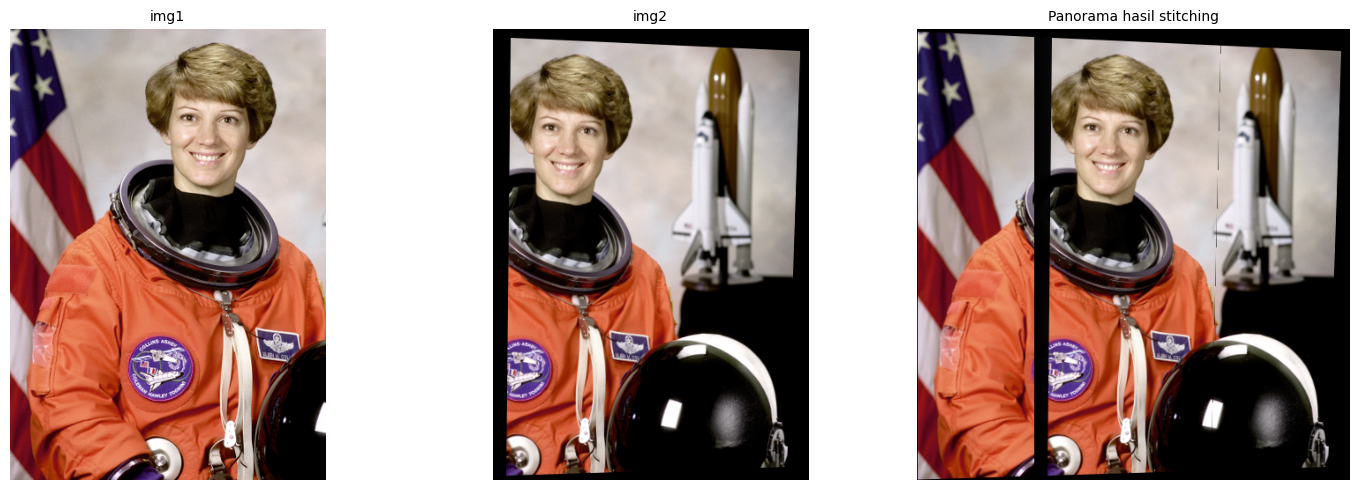

In [71]:
warped1 = cv2.warpPerspective(img1, T @ H_est, (canvas_w, canvas_h))
canvas = warped1.copy()

ox, oy = -xmin, -ymin
region = canvas[oy:oy + h2, ox:ox + w2]
warped1_mask = (cv2.cvtColor(warped1, cv2.COLOR_BGR2GRAY) > 0).astype(np.float32)
region_mask = warped1_mask[oy:oy + h2, ox:ox + w2]

# Pemaduan sederhana: ramp linear di daerah irisan, supaya garis sambung tidak keras.
alpha = np.tile(np.linspace(0, 1, w2), (h2, 1))
blend_weight = alpha * region_mask
blended = (region.astype(np.float32) * blend_weight[..., None] +
           img2.astype(np.float32) * (1 - blend_weight[..., None])).astype(np.uint8)
canvas[oy:oy + h2, ox:ox + w2] = blended

show((img1, "img1"), (img2, "img2"), (canvas, "Panorama hasil stitching"), figsize=(15, 5))

---
## Bonus (kalau waktu tersisa) · HOG

Dibahas di teori untuk deteksi pejalan kaki, tidak wajib untuk sesi ini. Lima baris untuk
mencoba detektor bawaan OpenCV:

In [72]:
if hasattr(cv2, "HOGDescriptor"):
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    boxes, weights = hog.detectMultiScale(img1, winStride=(8, 8))
    print(f"Kandidat pejalan kaki terdeteksi: {len(boxes)} (foto ini bukan foto jalanan, wajar 0 atau meleset)")
else:
    print("cv2.HOGDescriptor tidak tersedia di build OpenCV ini -- lewati bonus ini, tidak masalah.")

cv2.HOGDescriptor tidak tersedia di build OpenCV ini -- lewati bonus ini, tidak masalah.


---
## Ringkasan Fungsi Hari Ini

| Konsep | Fungsi OpenCV | Catatan |
|---|---|---|
| Gradien citra | `cv2.Sobel(img, cv2.CV_64F, dx, dy, ksize=3)` | dx=1,dy=0 untuk arah-x |
| Jendela pembobot | `cv2.GaussianBlur(img, (5,5), sigmaX=1.0)` | pada $I_x^2, I_y^2, I_xI_y$ |
| Sudut Harris (bawaan) | `cv2.cornerHarris(img, blockSize, ksize, k)` | pembanding hasil manual |
| Keypoint SIFT | `cv2.SIFT_create()` → `.detectAndCompute()` | deskriptor `(N,128) float32` |
| Keypoint ORB | `cv2.ORB_create(nfeatures=...)` → `.detectAndCompute()` | deskriptor `(N,32) uint8` |
| Pencocokan | `cv2.BFMatcher(norm)` → `.knnMatch(des1, des2, k=2)` | `NORM_L2` (SIFT) / `NORM_HAMMING` (ORB) |
| Uji rasio Lowe | `m.distance < ratio * n.distance` | `ratio` umum 0.7–0.8 |
| Homografi + RANSAC | `cv2.findHomography(src, dst, cv2.RANSAC, thresh)` | `thresh` dalam piksel |
| Transform titik | `cv2.perspectiveTransform(pts, H)` | untuk hitung kanvas |
| Warp citra | `cv2.warpPerspective(img, H, (w,h))` | gabungkan dengan matriks translasi `T` bila perlu |
| HOG (bonus) | `cv2.HOGDescriptor()` + `getDefaultPeopleDetector()` | deteksi pejalan kaki |

**Kenapa SURF tidak ada di sini:** SURF masih dipatenkan dan hanya tersedia di modul
*contrib non-free* OpenCV, tidak ikut terpasang di `opencv-python`/`opencv-python-headless`.
`cv2.xfeatures2d.SURF_create()` akan gagal di Colab. ORB adalah pengganti bebas lisensinya.

---

## Tugas Mandiri

Lihat pengumuman terpisah di grup kelas untuk instruksi lengkap dan tenggat waktu.